### Вигрузка датасету

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import datetime as dt
import squarify


path = "data/online_retail.csv"
df = pd.read_csv(path)
print(df.head())
print(df.shape)


  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
(541909, 8)


### Очистка датасету (за принципом користувач не має ID; кількість <=0; ціна одиниці <=0). Також переведено колонку дати покупки в формат дати та створено колонку суми покупки за принципом ціна*кількість

In [36]:
df = df.dropna(subset=['CustomerID'])
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["TotalSum"] = df["UnitPrice"] * df["Quantity"]
print(df.shape)

(397884, 9)


### Розбиваємо наш датасет на когорти за місяцем першої покупки

In [37]:
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period('M')
df["FirstMonth"] = df.groupby("CustomerID")["InvoiceMonth"].transform("min")
print(df[["InvoiceMonth", "FirstMonth"]].sample(10))

       InvoiceMonth FirstMonth
331779      2011-09    2010-12
59037       2011-01    2010-12
304709      2011-08    2011-08
260244      2011-07    2011-07
213171      2011-06    2010-12
159295      2011-04    2010-12
135922      2011-03    2011-03
376081      2011-10    2010-12
421119      2011-10    2011-10
249150      2011-07    2011-07


### Робомо когортну матрицю, де в рядках написані когорти, а в стопцях місяці їх "життя", а в клітинках відсоток повернувшихся людей

In [38]:
invoice_year = df['InvoiceMonth'].dt.year
invoice_month = df['InvoiceMonth'].dt.month
first_year = df['FirstMonth'].dt.year
first_month = df['FirstMonth'].dt.month
df['MonthDifference'] = (invoice_year - first_year) * 12 + (invoice_month - first_month) + 1
cohort_data = df.groupby(['FirstMonth', 'MonthDifference'])['CustomerID'].nunique().reset_index()
cohort_counts = cohort_data.pivot(index='FirstMonth', columns='MonthDifference', values='CustomerID')
cohort_sizes = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_sizes, axis=0)
(retention * 100).round(1).head(10)

MonthDifference,1,2,3,4,5,6,7,8,9,10,11,12,13
FirstMonth,,,,,,,,,,,,,
2010-12,100.0,36.6,32.3,38.4,36.3,39.8,36.3,34.9,35.4,39.5,37.4,50.3,26.6
2011-01,100.0,22.1,26.6,23.0,32.1,28.8,24.7,24.2,30.0,32.6,36.5,11.8,NaN
2011-02,100.0,18.7,18.7,28.4,27.1,24.7,25.3,27.9,24.7,30.5,6.8,NaN,NaN
2011-03,100.0,15.0,25.2,19.9,22.3,16.8,26.8,23.0,27.9,8.6,NaN,NaN,NaN
2011-04,100.0,21.3,20.3,21.0,19.7,22.7,21.7,26.0,7.3,NaN,NaN,NaN,NaN
2011-05,100.0,19.0,17.3,17.3,20.8,23.2,26.4,9.5,NaN,NaN,NaN,NaN,NaN
2011-06,100.0,17.4,15.7,26.4,23.1,33.5,9.5,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,100.0,18.1,20.7,22.3,27.1,11.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,100.0,20.7,24.9,24.3,12.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Робимо heatmap візуалізацію для нашої матриці

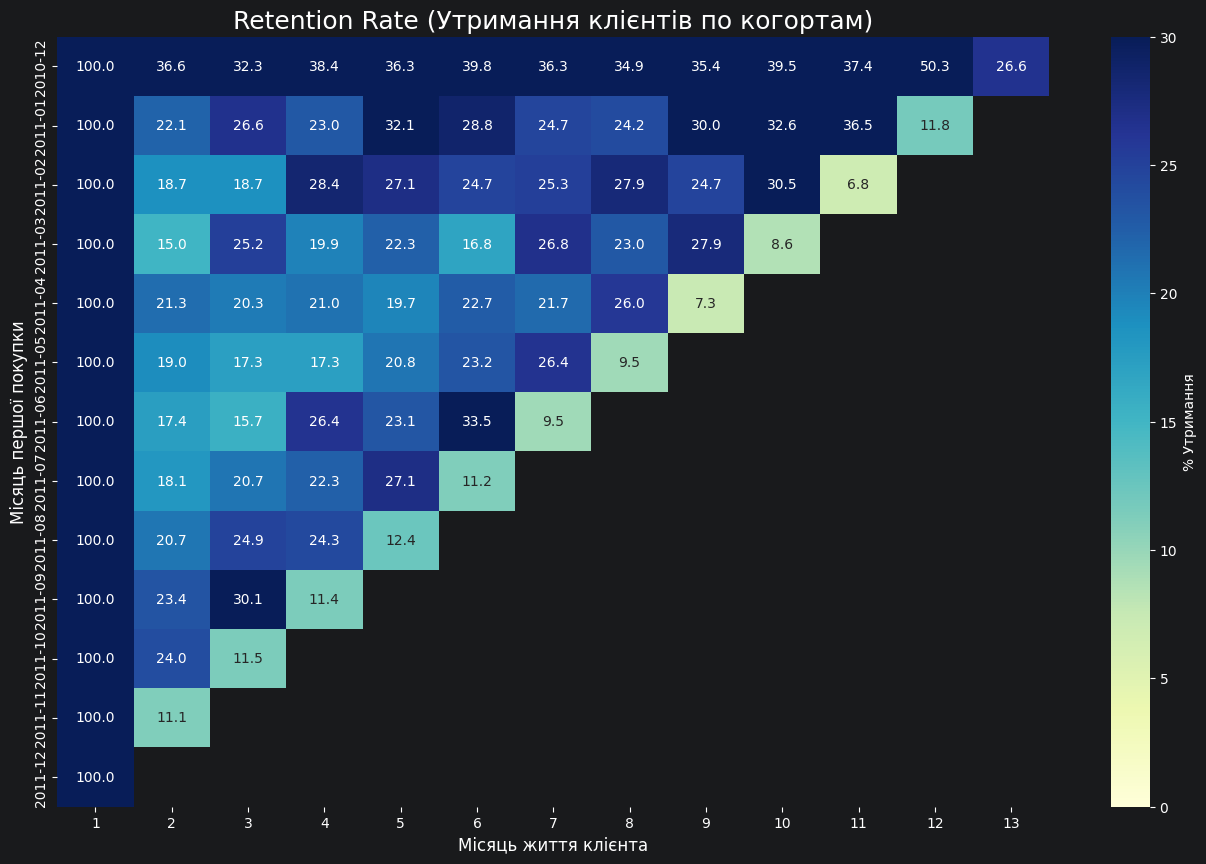

In [39]:
plt.figure(figsize=(16, 10))
plt.title('Retention Rate (Утримання клієнтів по когортам)', fontsize=18)
sns.heatmap(data=retention * 100,
            annot=True,
            fmt='.1f',
            vmin=0.0,
            vmax=30.0,
            cmap='YlGnBu',
            cbar_kws={'label': '% Утримання'})

plt.ylabel('Місяць першої покупки', fontsize=12)
plt.xlabel('Місяць життя клієнта', fontsize=12)
plt.show()

### RFM сегментація


In [40]:
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalSum': 'sum'
})

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSum': 'Monetary'
}, inplace=True)

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


### Скоринг (роздаємо оцінки від 1 до 5)

In [41]:
rfm['R'] = pd.qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1])
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5])
rfm['M'] = pd.qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5])
rfm['RFM_Score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
rfm.sample(10)

,Recency,Frequency,Monetary,R,F,M,RFM_Score
CustomerID,,,,,,,
13232.0,13,7,1357.60,5,5,4,554
15707.0,35,4,945.58,3,4,4,344
17418.0,42,2,463.46,3,3,2,332
15838.0,11,19,33643.08,5,5,5,555
14189.0,2,15,4654.08,5,5,5,555
17746.0,240,1,110.25,1,2,1,121
16097.0,240,1,185.05,1,2,1,121
13003.0,106,3,149.05,2,3,1,231
15808.0,306,4,3734.97,1,4,5,145


### Сегментація

In [42]:
segs = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At Risk',
    r'[1-2]5': 'Cant Loose Them',
    r'3[1-2]': 'About To Sleep',
    r'33': 'Need Attention',
    r'[3-4][4-5]': 'Loyal Customers',
    r'51': 'New Customers',
    r'41': 'Promising',
    r'[4-5][2-3]': 'Potential Loyalists',
    r'5[4-5]': 'Champions'
}

rfm['Segment'] = rfm['R'].astype(str) + rfm['F'].astype(str)
rfm['Segment'] = rfm['Segment'].replace(segs, regex=True)
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']
segment_counts

,Segment,Count
0,Hibernating,1065
1,Loyal Customers,827
2,Champions,633
3,At Risk,580
4,Potential Loyalists,492
5,About To Sleep,351
6,Need Attention,186
7,Promising,99
8,Cant Loose Them,63
9,New Customers,42


### Treemap візуалізація сегментів

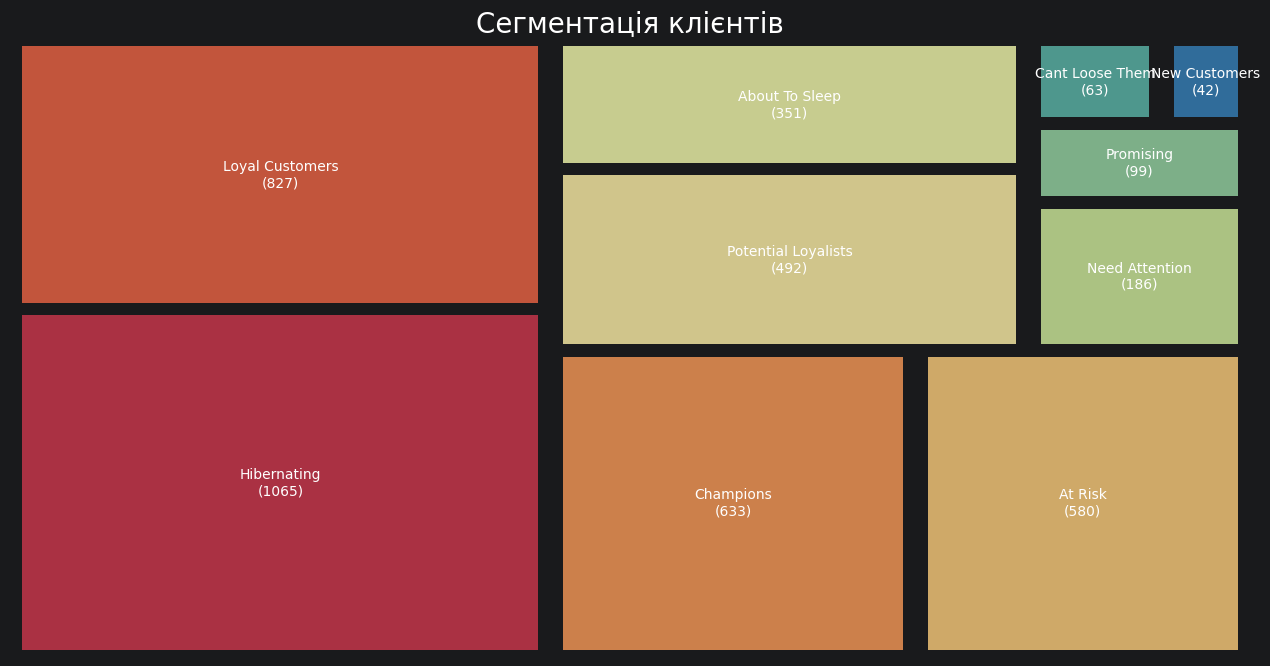

In [45]:
labels = [f'{s}\n({c})' for s, c in zip(segment_counts['Segment'], segment_counts['Count'])]
colors = sns.color_palette('Spectral', len(segment_counts))
plt.figure(figsize=(16, 8))
squarify.plot(sizes=segment_counts['Count'],
              label=labels,
              alpha=0.8,
              color=colors,
              pad=True)
plt.title('Сегментація клієнтів', fontsize=20)
plt.axis('off')
plt.show()